# Géron Ch.2 — End-to-End Machine Learning Project
**Dataset:** California Housing Prices (StatLib / 1990 Census, Géron's modified version)  
**Book:** Hands-On ML with Scikit-Learn, Keras & TensorFlow, 3rd ed.  
**Started:** 2026-05-17

---
Chapter road-map:
1. Look at the big picture
2. Get the data  ← *we are here*
3. Explore and visualise
4. Prepare the data (feature engineering)
5. Select and train a model
6. Fine-tune the model
7. Launch, monitor, maintain

## 0. Imports

In [1]:
import urllib.request
import tarfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

## 1. Get the Data

Géron hosts a slightly modified version of the StatLib dataset on his GitHub repo.  
Running `fetch_housing_data()` downloads it once into `data/housing.csv`.

In [2]:
# ── Data download ────────────────────────────────────────────────────────────
# Note: urllib silently gets dropped by GitHub (User-Agent policy).
# requests handles the redirect + headers correctly.
from pathlib import Path
import tarfile
import requests
import pandas as pd

def load_housing_data() -> pd.DataFrame:
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        print(f"Downloading {url} ...")
        response = requests.get(url, stream=True)
        response.raise_for_status()
        with open(tarball_path, "wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
        print("Saved to datasets/housing/housing.csv")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()
housing.shape

Saved to datasets/housing/housing.csv


(20640, 10)

In [3]:
# (housing is loaded above — this cell is now a no-op)
housing.shape

(20640, 10)

## 2. Quick Look at the Data

In [4]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
housing.info()
housing.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [11]:
# Calculate the % of missing values so to decide how to handle them.
housing.isnull().sum() / len(housing) * 100 

longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.002907
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64

In [21]:
housing["ocean_proximity"].value_counts()
housing[housing["total_bedrooms"].isnull()]["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     102
INLAND         55
NEAR OCEAN     30
NEAR BAY       20
Name: count, dtype: int64

In [22]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


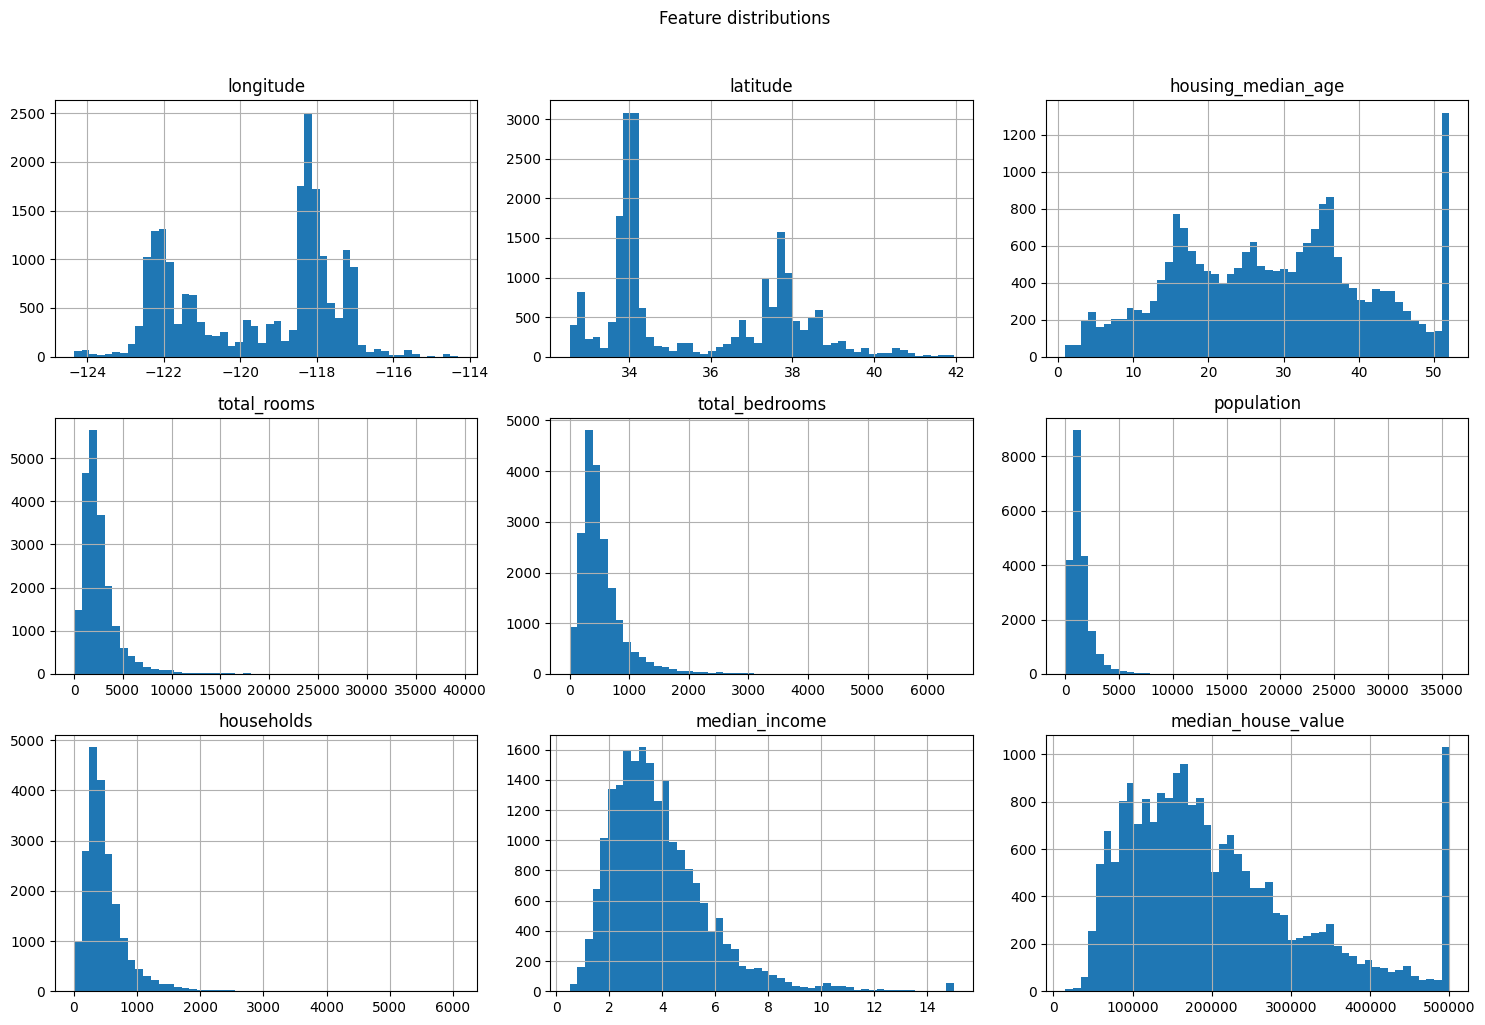

In [23]:
housing.hist(bins=50, figsize=(15, 10))
plt.suptitle("Feature distributions", y=1.02)
plt.tight_layout()
plt.show()

## 3. Train/Test Split

Géron stresses using **stratified sampling** on `median_income` to avoid sampling bias.

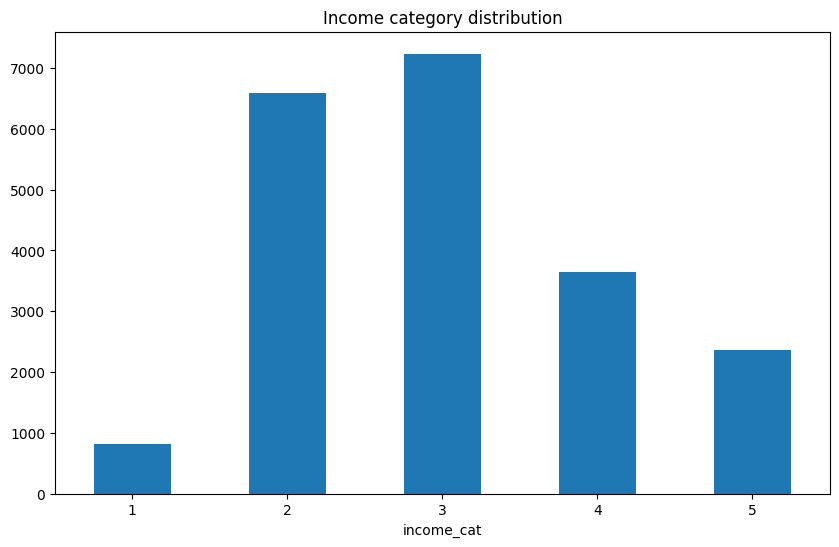

In [24]:
# Create an income category for stratification
housing["income_cat"] = pd.cut(
    housing["median_income"],
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5]
)
housing["income_cat"].value_counts().sort_index().plot.bar(rot=0)
plt.title("Income category distribution")
plt.show()

In [25]:
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in splitter.split(housing, housing["income_cat"]):
    strat_train_set = housing.iloc[train_idx]
    strat_test_set  = housing.iloc[test_idx]

# Drop the helper column
for dataset in (strat_train_set, strat_test_set):
    dataset.drop("income_cat", axis=1, inplace=True)

print(f"Train: {len(strat_train_set):,}  |  Test: {len(strat_test_set):,}")

Train: 16,512  |  Test: 4,128


## 4. Explore & Visualise (training set only)

> **Rule:** always explore with a *copy* so you can return to clean data.

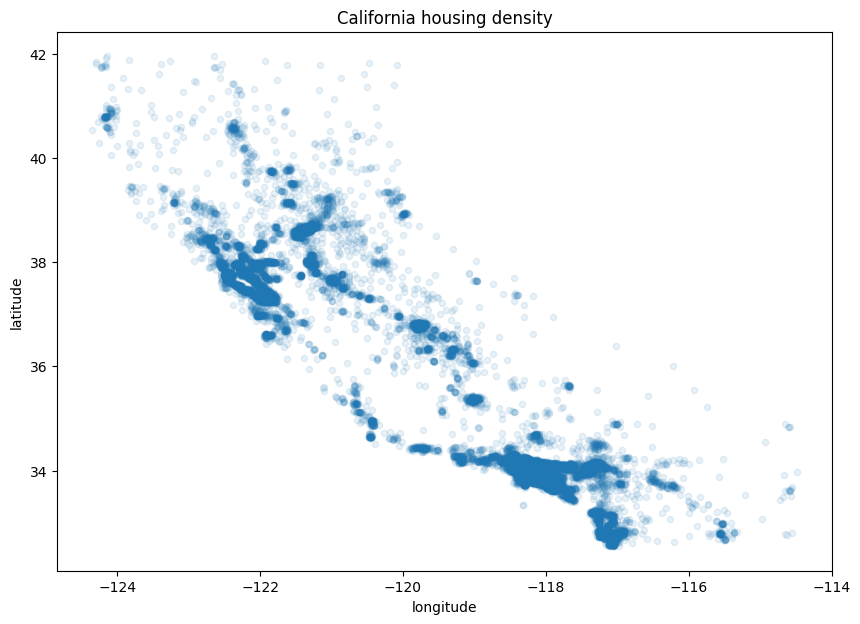

In [26]:
housing_eda = strat_train_set.copy()

# Geographic scatter — alpha helps reveal density
housing_eda.plot(
    kind="scatter", x="longitude", y="latitude",
    alpha=0.1, figsize=(10, 7),
    title="California housing density"
)
plt.show()

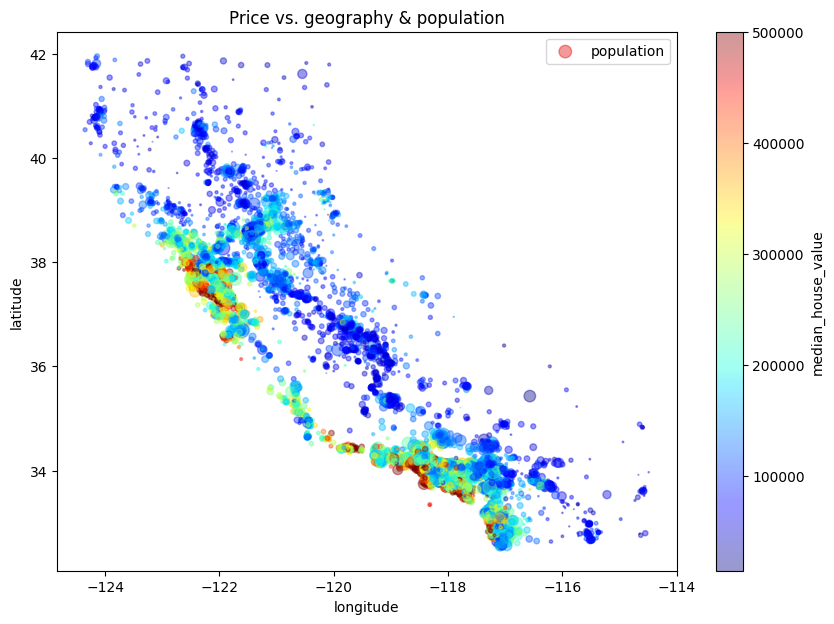

In [27]:
# Colour = price, size = population
housing_eda.plot(
    kind="scatter", x="longitude", y="latitude", alpha=0.4,
    s=housing_eda["population"] / 100, label="population",
    c="median_house_value", cmap=plt.get_cmap("jet"),
    colorbar=True, figsize=(10, 7),
    title="Price vs. geography & population"
)
plt.legend()
plt.show()

In [28]:
# Correlation matrix
corr_matrix = housing_eda.select_dtypes(include='number').corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

## 5. Feature Engineering

Géron's three new ratio features:

In [29]:
housing_eda["rooms_per_house"]   = housing_eda["total_rooms"]   / housing_eda["households"]
housing_eda["bedrooms_ratio"]    = housing_eda["total_bedrooms"] / housing_eda["total_rooms"]
housing_eda["people_per_house"]  = housing_eda["population"]    / housing_eda["households"]

corr_new = housing_eda.select_dtypes(include='number').corr()
corr_new["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
rooms_per_house       0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
people_per_house     -0.038224
longitude            -0.050859
latitude             -0.139584
bedrooms_ratio       -0.256397
Name: median_house_value, dtype: float64

In [41]:
from sklearn.feature_selection import mutual_info_regression

num = housing_eda.select_dtypes("number").dropna()   # MI errors on NaN — drop or impute first
X_mi = num.drop(columns="median_house_value")
y_mi = num["median_house_value"]

mi = mutual_info_regression(X_mi, y_mi, random_state=42)
pd.Series(mi, index=X_mi.columns).sort_values(ascending=False)

longitude             0.398029
median_income         0.385218
latitude              0.357562
bedrooms_ratio        0.138435
rooms_per_house       0.098717
people_per_house      0.066560
total_rooms           0.040481
housing_median_age    0.034571
population            0.026875
households            0.026192
total_bedrooms        0.020511
dtype: float64

In [31]:
# EDA on categorical features
#target encoding for exploration (not for the model — important distinction):
# Mean house value per category — reveals the signal immediately
housing_eda.groupby("ocean_proximity")["median_house_value"].agg(["mean", "median", "count"])

,mean,median,count
ocean_proximity,,,
<1H OCEAN,239747.487490,214800.0,7274
INLAND,124991.118091,109300.0,5301
ISLAND,450000.000000,450000.0,2
NEAR BAY,260416.009751,235200.0,1846
NEAR OCEAN,248372.410244,226500.0,2089


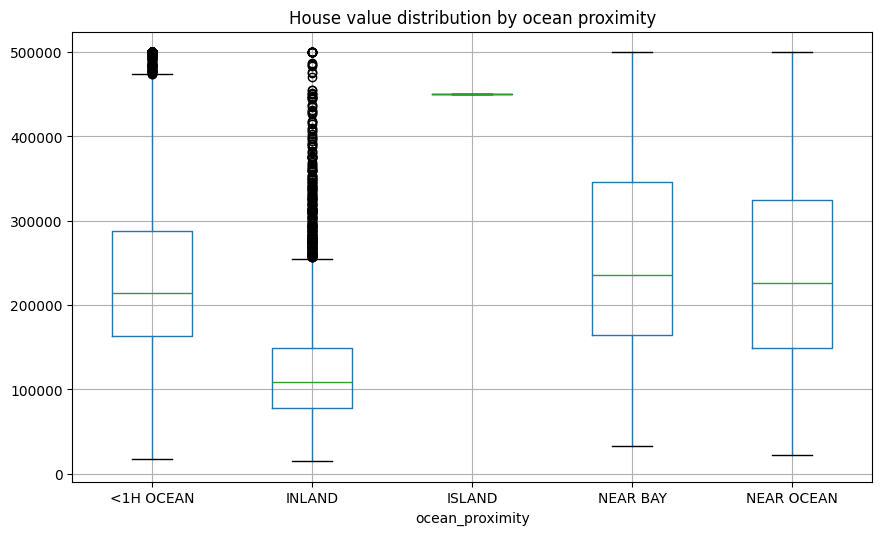

In [32]:
# Box plot — shows spread and outliers per category
housing_eda.boxplot(column="median_house_value", by="ocean_proximity", figsize=(10, 6))
plt.title("House value distribution by ocean proximity")
plt.suptitle("")  # suppress pandas auto-title
plt.show()

In [33]:
# Also worth asking: does ocean_proximity correlate with other features?
housing_eda.groupby("ocean_proximity")[["median_income", "housing_median_age", "population"]].mean()

,median_income,housing_median_age,population
ocean_proximity,,,
<1H OCEAN,4.231342,29.218174,1524.419027
INLAND,3.215251,24.267874,1376.918317
ISLAND,2.447000,39.500000,542.500000
NEAR BAY,4.179929,37.679848,1242.634886
NEAR OCEAN,4.004136,29.225945,1366.887985


## 6. Prepare Data for ML — sklearn Pipeline

> Work from the raw training set again, not the EDA copy.

In [34]:
from sklearn.base import BaseEstimator, TransformerMixin

# Separate features / target
housing_labels = strat_train_set["median_house_value"].copy()
housing_features = strat_train_set.drop("median_house_value", axis=1)

# Column groups
num_cols = list(housing_features.select_dtypes(include='number').columns)
cat_cols = ["ocean_proximity"]

print("Numeric:", num_cols)
print("Categorical:", cat_cols)

Numeric: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Categorical: ['ocean_proximity']


In [37]:
# Custom transformer to add ratio features inside the pipeline
class RatioFeatureAdder(BaseEstimator, TransformerMixin):
    """Adds rooms_per_house, bedrooms_ratio, people_per_house."""

    # Column indices (relative to the numeric subset fed in)
    def __init__(
        self,
        rooms_ix: int = 3,
        bedrooms_ix: int = 4,
        population_ix: int = 5,
        households_ix: int = 6,
    ) -> None:
        self.rooms_ix      = rooms_ix
        self.bedrooms_ix   = bedrooms_ix
        self.population_ix = population_ix
        self.households_ix = households_ix

    def fit(self, X: np.ndarray, y=None) -> "RatioFeatureAdder":
        return self  # nothing to learn

    def transform(self, X: np.ndarray) -> np.ndarray:
        rooms_per_house  = X[:, self.rooms_ix]      / X[:, self.households_ix]
        bedrooms_ratio   = X[:, self.bedrooms_ix]   / X[:, self.rooms_ix]
        people_per_house = X[:, self.population_ix] / X[:, self.households_ix]
        return np.c_[X, rooms_per_house, bedrooms_ratio, people_per_house]


num_pipeline = Pipeline([
    ("imputer",  SimpleImputer(strategy="median")),
    ("attribs",  RatioFeatureAdder()),
    ("scaler",   StandardScaler()),
])

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", OneHotEncoder(), cat_cols),
])

X_train = full_pipeline.fit_transform(housing_features)
y_train = housing_labels.to_numpy()

print("X_train shape:", X_train.shape)

X_train shape: (16512, 16)


## 7. Train & Evaluate Models

In [38]:
def rmse_cv(model, X=X_train, y=y_train, cv: int = 10) -> None:
    """Print cross-validated RMSE (mean ± std)."""
    scores = cross_val_score(
        model, X, y, scoring="neg_mean_squared_error", cv=cv
    )
    rmse = np.sqrt(-scores)
    print(f"{model.__class__.__name__}")
    print(f"  RMSE  mean: {rmse.mean():,.0f}")
    print(f"  RMSE  std : {rmse.std():,.0f}")

In [39]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
rmse_cv(lin_reg)

LinearRegression
  RMSE  mean: 67,994
  RMSE  std : 1,395


In [ ]:
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train, y_train)
rmse_cv(tree_reg)

In [ ]:
forest_reg = RandomForestRegressor(n_estimators=100, random_state=42)
forest_reg.fit(X_train, y_train)
rmse_cv(forest_reg)

## 8. Final Evaluation on Test Set

> Only do this **once** — looking at the test set repeatedly is a form of data leakage.

In [ ]:
# Prepare test set using the ALREADY-FITTED pipeline
X_test = full_pipeline.transform(
    strat_test_set.drop("median_house_value", axis=1)
)
y_test = strat_test_set["median_house_value"].to_numpy()

final_pred = forest_reg.predict(X_test)
final_rmse = np.sqrt(mean_squared_error(y_test, final_pred))
print(f"Final test RMSE (RandomForest): ${final_rmse:,.0f}")

---
### Notes / Questions

- *(add your observations as you read)*